In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

In [3]:
df = pd.read_excel("Air quality information.xlsx")
df

,last_updated_epoch,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,1693000001,243.7,45.8,1.7,3.1,12.6,18.5,1,2
1,1693000002,240.3,38.3,2.1,2.6,10.7,14.2,1,1
2,1693000003,220.3,57.2,0.6,1.7,16.8,20.7,2,2
3,1693000004,200.3,25.0,1.2,1.1,4.9,6.6,1,1
4,1693000005,257.0,30.8,2.2,1.8,11.4,14.8,1,1
...,...,...,...,...,...,...,...,...,...
24065,1693024066,2162.9,0.1,35.0,8.0,181.4,295.9,5,10
24066,1693024067,297.1,3.3,2.1,0.4,28.2,29.3,2,3
24067,1693024068,480.7,60.8,5.5,2.4,42.0,45.7,3,5
24068,1693024069,297.1,42.9,2.8,1.3,12.8,13.8,1,2


In [4]:
df.head()

,last_updated_epoch,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,1693000001,243.7,45.8,1.7,3.1,12.6,18.5,1,2
1,1693000002,240.3,38.3,2.1,2.6,10.7,14.2,1,1
2,1693000003,220.3,57.2,0.6,1.7,16.8,20.7,2,2
3,1693000004,200.3,25.0,1.2,1.1,4.9,6.6,1,1
4,1693000005,257.0,30.8,2.2,1.8,11.4,14.8,1,1


In [6]:
df=pd.DataFrame(df)
print(df)

       last_updated_epoch  air_quality_Carbon_Monoxide  air_quality_Ozone  \
0              1693000001                        243.7               45.8   
1              1693000002                        240.3               38.3   
2              1693000003                        220.3               57.2   
3              1693000004                        200.3               25.0   
4              1693000005                        257.0               30.8   
...                   ...                          ...                ...   
24065          1693024066                       2162.9                0.1   
24066          1693024067                        297.1                3.3   
24067          1693024068                        480.7               60.8   
24068          1693024069                        297.1               42.9   
24069          1693024070                        407.2               47.2   

       air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  \
0      

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24070 entries, 0 to 24069
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   last_updated_epoch            24070 non-null  int64  
 1   air_quality_Carbon_Monoxide   24070 non-null  float64
 2   air_quality_Ozone             24070 non-null  float64
 3   air_quality_Nitrogen_dioxide  24070 non-null  float64
 4   air_quality_Sulphur_dioxide   24070 non-null  float64
 5   air_quality_PM2.5             24070 non-null  float64
 6   air_quality_PM10              24070 non-null  float64
 7   air_quality_us-epa-index      24070 non-null  int64  
 8   air_quality_gb-defra-index    24070 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 1.7 MB


In [9]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Display basic statistics
print("\nBasic statistics:")
print(df.describe())

Missing values:
last_updated_epoch              0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
dtype: int64

Duplicate rows:
0

Basic statistics:
       last_updated_epoch  air_quality_Carbon_Monoxide  air_quality_Ozone  \
count        2.407000e+04                 24070.000000       24070.000000   
mean         1.693012e+09                   594.928396          26.401774   
std          6.948555e+03                   515.120689          22.886129   
min          1.693000e+09                   113.500000           0.000000   
25%          1.693006e+09                   287.100000           9.400000   
50%          1.693012e+09                   454.000000          21.300000   
75%          1.693018e+09                   734.300000          37.200000   
max        

In [10]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values by filling with mean for numerical columns
df = df.fillna(df.mean(numeric_only=True))

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Data cleaning completed!")
print(f"Shape after cleaning: {df.shape}")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Data cleaning completed!
Shape after cleaning: (24070, 9)

Missing values after cleaning:
last_updated_epoch              0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
dtype: int64


In [12]:
df=pd.read_csv("merged-2026-08-17.csv")
df

/var/folders/nc/6_1vctrx2z73rhr1y8qh9yw40000gn/T/ipykernel_3542/4290864941.py:1: DtypeWarning: Columns (0: sunrise, 1: sunset, 2: moonrise, 3: moonset, 4: moon_phase, 5: country, 6: location_name, 7: region, 8: timezone, 9: last_updated, 10: wind_direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("merged-2026-08-17.csv")


,last_updated_epoch,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,...,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph
0,1693000001,243.7,45.8,1.7,3.1,12.6,18.5,1.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1693000002,240.3,38.3,2.1,2.6,10.7,14.2,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1693000003,220.3,57.2,0.6,1.7,16.8,20.7,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1693000004,200.3,25.0,1.2,1.1,4.9,6.6,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1693000005,257.0,30.8,2.2,1.8,11.4,14.8,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96275,1693024066,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,70.0,0.0,26.7,80.0,2.5,1.0,1.0,8.0,12.9
96276,1693024067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,99.0,100.0,25.1,77.1,0.0,0.0,1.0,1.4,2.2
96277,1693024068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,90.0,71.0,27.3,81.2,9.0,5.0,1.0,3.1,4.9
96278,1693024069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,88.0,75.0,24.6,76.3,10.0,6.0,1.0,11.5,18.5


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96280 entries, 0 to 96279
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   last_updated_epoch            96280 non-null  int64  
 1   air_quality_Carbon_Monoxide   24070 non-null  float64
 2   air_quality_Ozone             24070 non-null  float64
 3   air_quality_Nitrogen_dioxide  24070 non-null  float64
 4   air_quality_Sulphur_dioxide   24070 non-null  float64
 5   air_quality_PM2.5             24070 non-null  float64
 6   air_quality_PM10              24070 non-null  float64
 7   air_quality_us-epa-index      24070 non-null  float64
 8   air_quality_gb-defra-index    24070 non-null  float64
 9   sunrise                       24070 non-null  str    
 10  sunset                        24070 non-null  str    
 11  moonrise                      24070 non-null  str    
 12  moonset                       24070 non-null  str    
 13  moon_phase  

In [14]:
df.head()


,last_updated_epoch,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,...,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph
0,1693000001,243.7,45.8,1.7,3.1,12.6,18.5,1.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1693000002,240.3,38.3,2.1,2.6,10.7,14.2,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1693000003,220.3,57.2,0.6,1.7,16.8,20.7,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1693000004,200.3,25.0,1.2,1.1,4.9,6.6,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1693000005,257.0,30.8,2.2,1.8,11.4,14.8,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum()

last_updated_epoch                  0
air_quality_Carbon_Monoxide     72210
air_quality_Ozone               72210
air_quality_Nitrogen_dioxide    72210
air_quality_Sulphur_dioxide     72210
air_quality_PM2.5               72210
air_quality_PM10                72210
air_quality_us-epa-index        72210
air_quality_gb-defra-index      72210
sunrise                         72210
sunset                          72210
moonrise                        72210
moonset                         72210
moon_phase                      72210
moon_illumination               72210
country                         72210
location_name                   72210
region                          72210
latitude                        72210
longitude                       72210
timezone                        72210
last_updated                    72210
temperature_celsius             72210
temperature_fahrenheit          72210
wind_mph                        72210
wind_kph                        72210
wind_degree 

In [16]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

Shape:
(96280, 41)

Columns:
Index(['last_updated_epoch', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination',
       'country', 'location_name', 'region', 'latitude', 'longitude',
       'timezone', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm',
       'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph'],
      dtype='str')

Data Types:
last_updated_epoch                int64
air_quality_Carbon_Monoxide     float64
air_quality_Ozone               float64
air_quality_Nitrogen_diox

In [17]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 96280 entries, 0 to 96279
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   last_updated_epoch            96280 non-null  int64  
 1   air_quality_Carbon_Monoxide   24070 non-null  float64
 2   air_quality_Ozone             24070 non-null  float64
 3   air_quality_Nitrogen_dioxide  24070 non-null  float64
 4   air_quality_Sulphur_dioxide   24070 non-null  float64
 5   air_quality_PM2.5             24070 non-null  float64
 6   air_quality_PM10              24070 non-null  float64
 7   air_quality_us-epa-index      24070 non-null  float64
 8   air_quality_gb-defra-index    24070 non-null  float64
 9   sunrise                       24070 non-null  str    
 10  sunset                        24070 non-null  str    
 11  moonrise                      24070 non-null  str    
 12  moonset                       24070 non-null  str    
 13  moon_phase  

In [18]:
print(df.describe())

       last_updated_epoch  air_quality_Carbon_Monoxide  air_quality_Ozone  \
count        9.628000e+04                 24070.000000       24070.000000   
mean         1.693012e+09                   594.928396          26.401774   
std          6.948447e+03                   515.120689          22.886129   
min          1.693000e+09                   113.500000           0.000000   
25%          1.693006e+09                   287.100000           9.400000   
50%          1.693012e+09                   454.000000          21.300000   
75%          1.693018e+09                   734.300000          37.200000   
max          1.693024e+09                 11642.500000         171.700000   

       air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  \
count                  24070.000000                 24070.000000   
mean                       9.238525                     4.721246   
std                        9.582348                    11.501504   
min                        0.00000

In [19]:
missing = df.isnull().sum()
print(missing)

last_updated_epoch                  0
air_quality_Carbon_Monoxide     72210
air_quality_Ozone               72210
air_quality_Nitrogen_dioxide    72210
air_quality_Sulphur_dioxide     72210
air_quality_PM2.5               72210
air_quality_PM10                72210
air_quality_us-epa-index        72210
air_quality_gb-defra-index      72210
sunrise                         72210
sunset                          72210
moonrise                        72210
moonset                         72210
moon_phase                      72210
moon_illumination               72210
country                         72210
location_name                   72210
region                          72210
latitude                        72210
longitude                       72210
timezone                        72210
last_updated                    72210
temperature_celsius             72210
temperature_fahrenheit          72210
wind_mph                        72210
wind_kph                        72210
wind_degree 

In [20]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False))

timezone                        75.0
last_updated                    75.0
temperature_fahrenheit          75.0
wind_mph                        75.0
wind_kph                        75.0
wind_degree                     75.0
wind_direction                  75.0
pressure_mb                     75.0
pressure_in                     75.0
precip_mm                       75.0
precip_in                       75.0
humidity                        75.0
cloud                           75.0
feels_like_celsius              75.0
feels_like_fahrenheit           75.0
visibility_km                   75.0
visibility_miles                75.0
uv_index                        75.0
gust_mph                        75.0
temperature_celsius             75.0
gust_kph                        75.0
air_quality_Carbon_Monoxide     75.0
longitude                       75.0
air_quality_Ozone               75.0
air_quality_Nitrogen_dioxide    75.0
air_quality_Sulphur_dioxide     75.0
air_quality_PM2.5               75.0
a

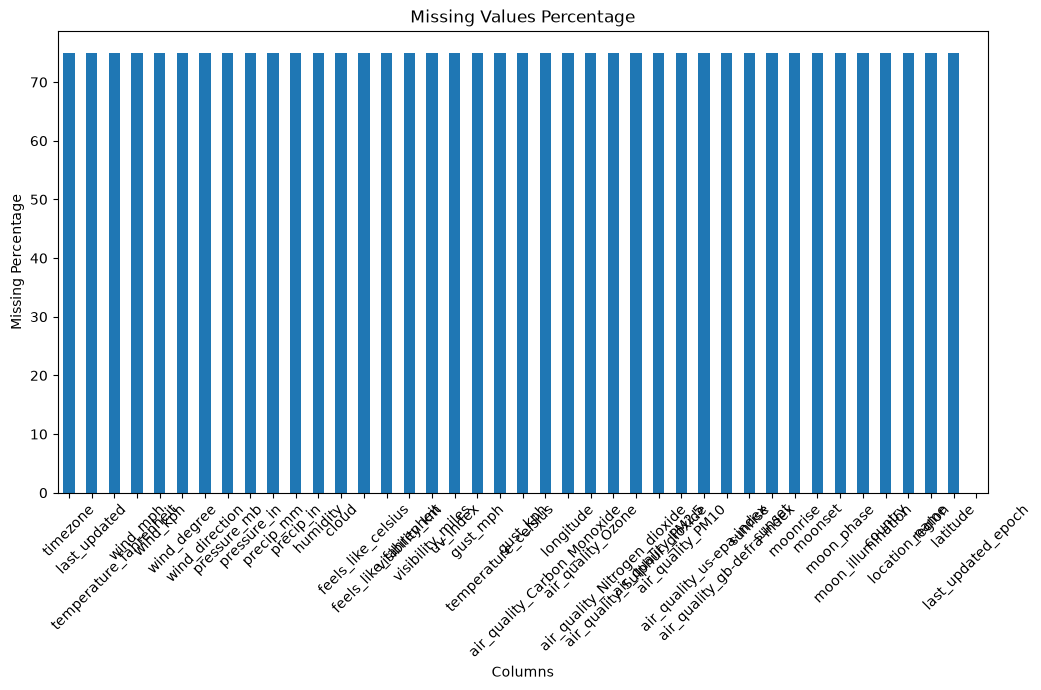

In [21]:
plt.figure(figsize=(12, 6))

missing_percentage.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values Percentage")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)

plt.show()

In [22]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [23]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96280, 41)


In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns)

Index(['last_updated_epoch', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index',
       'moon_illumination', 'latitude', 'longitude', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph'],
      dtype='str')


In [25]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'country',
       'location_name', 'region', 'timezone', 'last_updated',
       'wind_direction'],
      dtype='str')


/var/folders/nc/6_1vctrx2z73rhr1y8qh9yw40000gn/T/ipykernel_3542/1123855639.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [26]:
print(df.describe().T)

                                count          mean          std  \
last_updated_epoch            96280.0  1.693012e+09  6948.446568   
air_quality_Carbon_Monoxide   24070.0  5.949284e+02   515.120689   
air_quality_Ozone             24070.0  2.640177e+01    22.886129   
air_quality_Nitrogen_dioxide  24070.0  9.238525e+00     9.582348   
air_quality_Sulphur_dioxide   24070.0  4.721246e+00    11.501504   
air_quality_PM2.5             24070.0  5.072829e+01    61.950171   
air_quality_PM10              24070.0  6.278135e+01    73.728859   
air_quality_us-epa-index      24070.0  2.408725e+00     1.336316   
air_quality_gb-defra-index    24070.0  4.542792e+00     3.580995   
moon_illumination             24070.0  5.498118e+01    34.926868   
latitude                      24070.0  2.309953e+01     5.796304   
longitude                     24070.0  8.023766e+01     5.757138   
temperature_celsius           24070.0  2.432317e+01     3.901488   
temperature_fahrenheit        24070.0  7.578147e

In [27]:
print("Average values:")

print(df[numeric_columns].mean())

Average values:
last_updated_epoch              1.693012e+09
air_quality_Carbon_Monoxide     5.949284e+02
air_quality_Ozone               2.640177e+01
air_quality_Nitrogen_dioxide    9.238525e+00
air_quality_Sulphur_dioxide     4.721246e+00
air_quality_PM2.5               5.072829e+01
air_quality_PM10                6.278135e+01
air_quality_us-epa-index        2.408725e+00
air_quality_gb-defra-index      4.542792e+00
moon_illumination               5.498118e+01
latitude                        2.309953e+01
longitude                       8.023766e+01
temperature_celsius             2.432317e+01
temperature_fahrenheit          7.578147e+01
wind_mph                        5.512256e+00
wind_kph                        8.875347e+00
wind_degree                     1.869256e+02
pressure_mb                     1.006049e+03
pressure_in                     2.970819e+01
precip_mm                       2.844254e-01
precip_in                       1.105235e-02
humidity                        8.05933

In [28]:
print("Average values:")

print(df[numeric_columns].mean())

Average values:
last_updated_epoch              1.693012e+09
air_quality_Carbon_Monoxide     5.949284e+02
air_quality_Ozone               2.640177e+01
air_quality_Nitrogen_dioxide    9.238525e+00
air_quality_Sulphur_dioxide     4.721246e+00
air_quality_PM2.5               5.072829e+01
air_quality_PM10                6.278135e+01
air_quality_us-epa-index        2.408725e+00
air_quality_gb-defra-index      4.542792e+00
moon_illumination               5.498118e+01
latitude                        2.309953e+01
longitude                       8.023766e+01
temperature_celsius             2.432317e+01
temperature_fahrenheit          7.578147e+01
wind_mph                        5.512256e+00
wind_kph                        8.875347e+00
wind_degree                     1.869256e+02
pressure_mb                     1.006049e+03
pressure_in                     2.970819e+01
precip_mm                       2.844254e-01
precip_in                       1.105235e-02
humidity                        8.05933

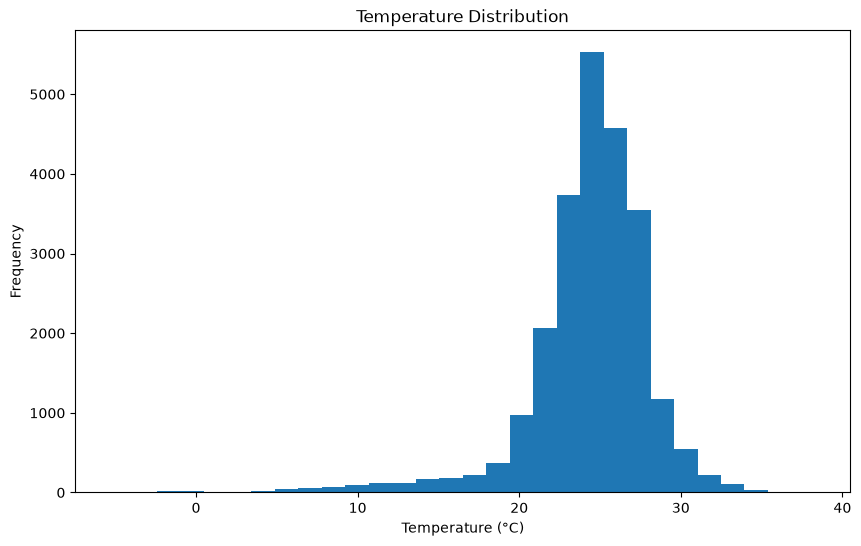

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(df["temperature_celsius"], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

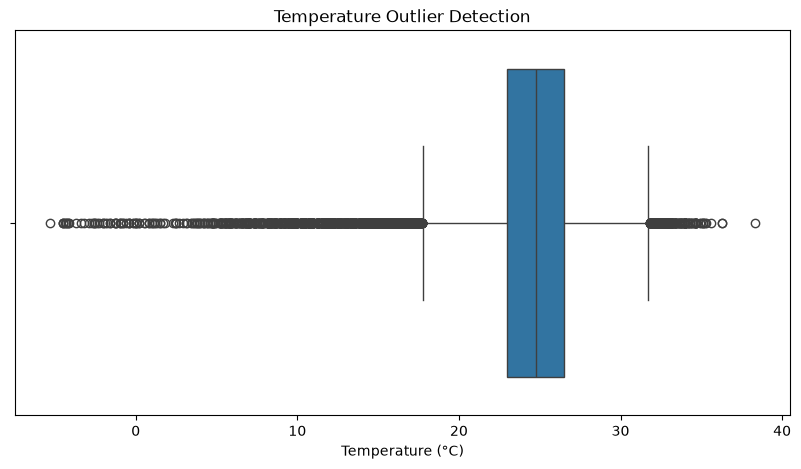

In [30]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["temperature_celsius"])

plt.title("Temperature Outlier Detection")
plt.xlabel("Temperature (°C)")

plt.show()

In [31]:
correlation = df[numeric_columns].corr()

print(correlation)

                              last_updated_epoch  air_quality_Carbon_Monoxide  \
last_updated_epoch                      1.000000                     0.158753   
air_quality_Carbon_Monoxide             0.158753                     1.000000   
air_quality_Ozone                      -0.044896                    -0.251381   
air_quality_Nitrogen_dioxide            0.137266                     0.724569   
air_quality_Sulphur_dioxide            -0.016645                     0.384199   
air_quality_PM2.5                       0.228454                     0.851089   
air_quality_PM10                        0.243030                     0.841257   
air_quality_us-epa-index                0.234121                     0.700009   
air_quality_gb-defra-index              0.222142                     0.618172   
moon_illumination                      -0.082777                          NaN   
latitude                               -0.005191                          NaN   
longitude                   

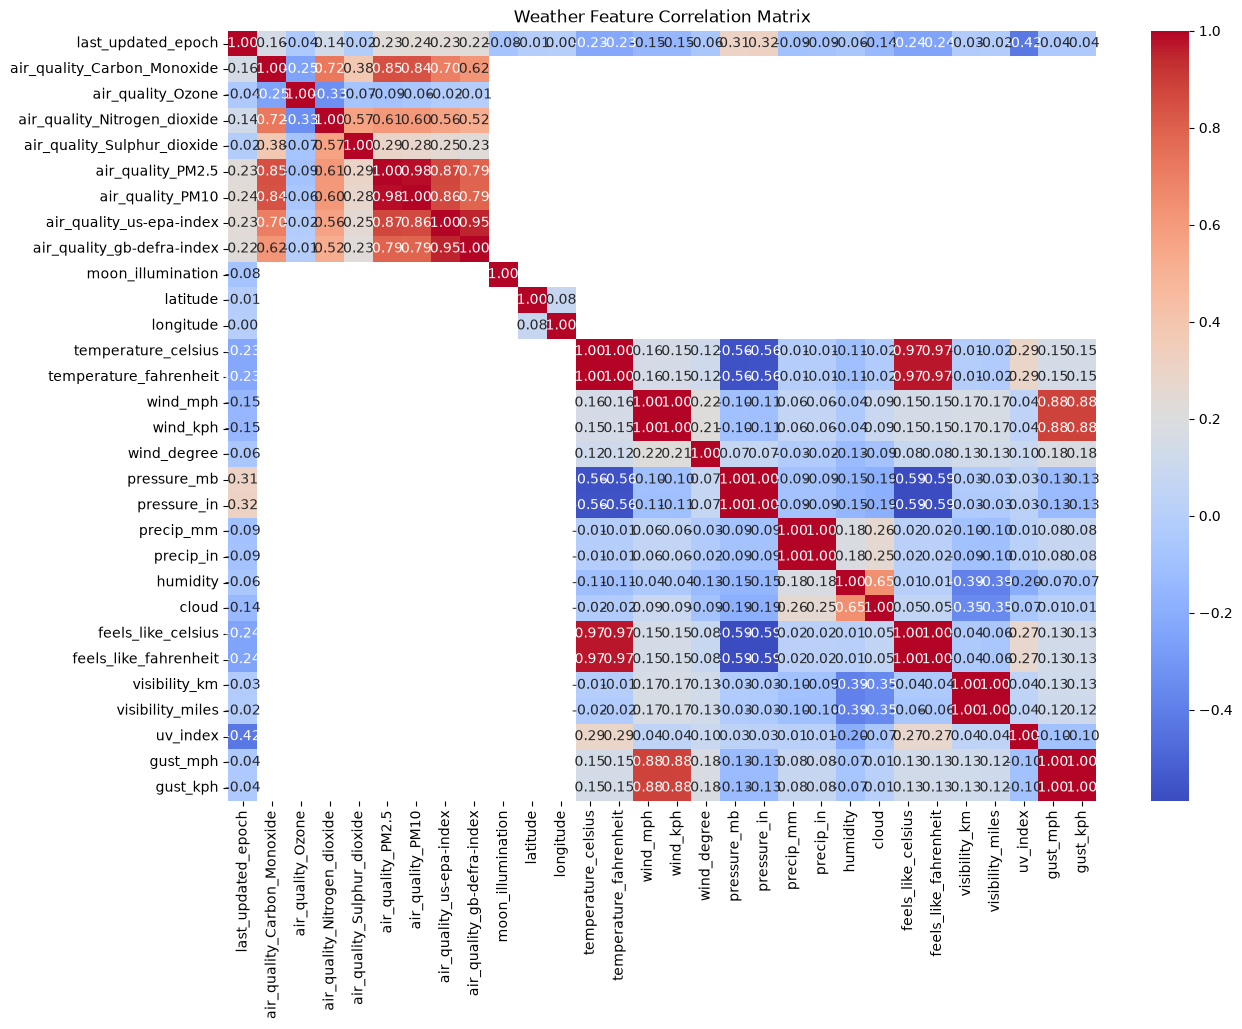

In [32]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather Feature Correlation Matrix")

plt.show()

In [35]:
print("Number of rows and columns:")
print(df.shape)

print("\nActual column names:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

print("\nFirst 5 rows:")
display(df.head())

Number of rows and columns:
(96280, 41)

Actual column names:
0 'last_updated_epoch'
1 'air_quality_Carbon_Monoxide'
2 'air_quality_Ozone'
3 'air_quality_Nitrogen_dioxide'
4 'air_quality_Sulphur_dioxide'
5 'air_quality_PM2.5'
6 'air_quality_PM10'
7 'air_quality_us-epa-index'
8 'air_quality_gb-defra-index'
9 'sunrise'
10 'sunset'
11 'moonrise'
12 'moonset'
13 'moon_phase'
14 'moon_illumination'
15 'country'
16 'location_name'
17 'region'
18 'latitude'
19 'longitude'
20 'timezone'
21 'last_updated'
22 'temperature_celsius'
23 'temperature_fahrenheit'
24 'wind_mph'
25 'wind_kph'
26 'wind_degree'
27 'wind_direction'
28 'pressure_mb'
29 'pressure_in'
30 'precip_mm'
31 'precip_in'
32 'humidity'
33 'cloud'
34 'feels_like_celsius'
35 'feels_like_fahrenheit'
36 'visibility_km'
37 'visibility_miles'
38 'uv_index'
39 'gust_mph'
40 'gust_kph'

First 5 rows:


,last_updated_epoch,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,...,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph
0,1693000001,243.7,45.8,1.7,3.1,12.6,18.5,1.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1693000002,240.3,38.3,2.1,2.6,10.7,14.2,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1693000003,220.3,57.2,0.6,1.7,16.8,20.7,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1693000004,200.3,25.0,1.2,1.1,4.9,6.6,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1693000005,257.0,30.8,2.2,1.8,11.4,14.8,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 96280 entries, 0 to 96279
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   last_updated_epoch            96280 non-null  int64  
 1   air_quality_Carbon_Monoxide   24070 non-null  float64
 2   air_quality_Ozone             24070 non-null  float64
 3   air_quality_Nitrogen_dioxide  24070 non-null  float64
 4   air_quality_Sulphur_dioxide   24070 non-null  float64
 5   air_quality_PM2.5             24070 non-null  float64
 6   air_quality_PM10              24070 non-null  float64
 7   air_quality_us-epa-index      24070 non-null  float64
 8   air_quality_gb-defra-index    24070 non-null  float64
 9   sunrise                       24070 non-null  str    
 10  sunset                        24070 non-null  str    
 11  moonrise                      24070 non-null  str    
 12  moonset                       24070 non-null  str    
 13  moon_phase  

In [37]:
print(df.columns.tolist())


['last_updated_epoch', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'country', 'location_name', 'region', 'latitude', 'longitude', 'timezone', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph']


In [38]:
missing = df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

air_quality_Carbon_Monoxide     72210
air_quality_Ozone               72210
temperature_fahrenheit          72210
wind_mph                        72210
wind_kph                        72210
wind_degree                     72210
wind_direction                  72210
pressure_mb                     72210
pressure_in                     72210
precip_mm                       72210
precip_in                       72210
humidity                        72210
cloud                           72210
feels_like_celsius              72210
feels_like_fahrenheit           72210
visibility_km                   72210
visibility_miles                72210
uv_index                        72210
gust_mph                        72210
temperature_celsius             72210
last_updated                    72210
timezone                        72210
sunset                          72210
air_quality_Nitrogen_dioxide    72210
air_quality_Sulphur_dioxide     72210
air_quality_PM2.5               72210
air_quality_

In [39]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

air_quality_Carbon_Monoxide     75.0
air_quality_Ozone               75.0
temperature_fahrenheit          75.0
wind_mph                        75.0
wind_kph                        75.0
wind_degree                     75.0
wind_direction                  75.0
pressure_mb                     75.0
pressure_in                     75.0
precip_mm                       75.0
precip_in                       75.0
humidity                        75.0
cloud                           75.0
feels_like_celsius              75.0
feels_like_fahrenheit           75.0
visibility_km                   75.0
visibility_miles                75.0
uv_index                        75.0
gust_mph                        75.0
temperature_celsius             75.0
last_updated                    75.0
timezone                        75.0
sunset                          75.0
air_quality_Nitrogen_dioxide    75.0
air_quality_Sulphur_dioxide     75.0
air_quality_PM2.5               75.0
air_quality_PM10                75.0
a

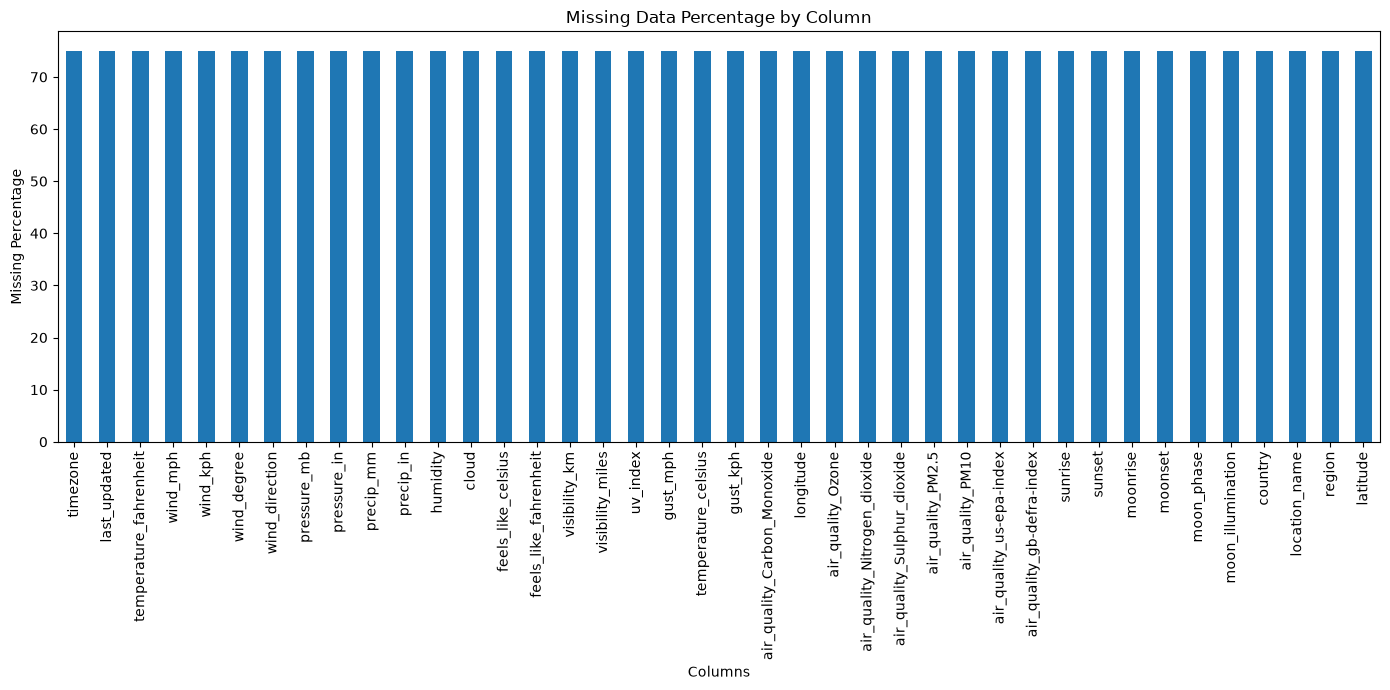

In [40]:
import matplotlib.pyplot as plt

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(14, 7))

missing_percentage.plot(kind="bar")

plt.title("Missing Data Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [41]:
print(df.notnull().sum(axis=1).value_counts().sort_index())

7     24070
8     24070
9     24070
20    24070
Name: count, dtype: int64


In [42]:
df["missing_count"] = df.isnull().sum(axis=1)

print(df["missing_count"].describe())

count    96280.000000
mean        30.000000
std          5.244071
min         21.000000
25%         29.250000
50%         32.500000
75%         33.250000
max         34.000000
Name: missing_count, dtype: float64


In [43]:
print(
    df["missing_count"].value_counts().sort_index()
)

missing_count
21    24070
32    24070
33    24070
34    24070
Name: count, dtype: int64


In [46]:
print(df["location_name"].value_counts())

location_name
Udaipur          84
East Godavari    74
Siang            70
Barddhaman       65
Kolkata          64
                 ..
Seoni            43
Anantnag         43
Hassan           43
Palghar          43
Mancherial       43
Name: count, Length: 543, dtype: int64


In [47]:
print(df["country"].value_counts())

country
India    24070
Name: count, dtype: int64


In [48]:
print(
    df["region"].value_counts().head(20)
)

region
Uttar Pradesh        2687
Madhya Pradesh       2110
Rajasthan            1597
Andhra Pradesh       1437
Maharashtra          1413
Bihar                1276
Tamil Nadu           1232
Orissa               1084
Karnataka            1017
Gujarat              1012
Chhattisgarh         1012
Assam                 926
West Bengal           922
Haryana               880
Jammu and Kashmir     879
Punjab                836
Jharkhand             792
Kerala                616
Uttarakhand           484
Manipur               353
Name: count, dtype: int64


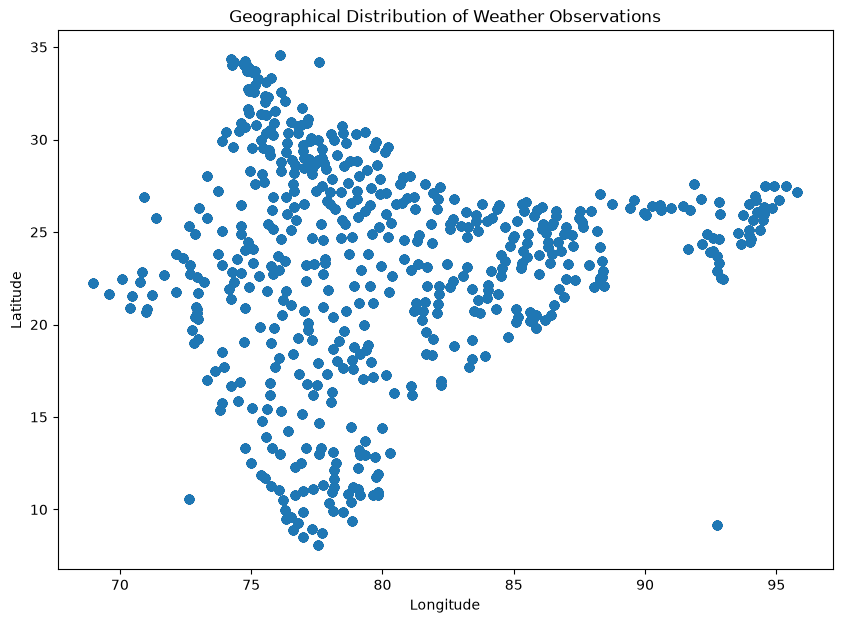

In [49]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Geographical Distribution of Weather Observations")

plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df["last_updated_epoch"]

NameError: name 'df' is not defined

In [6]:
print(df.shape)
print(df.columns.tolist())

NameError: name 'df' is not defined